Summary: Introduction to the walkthrough lab on Clustering (K-Means, DBSCAN, HDBSCAN) and Dimensionality Reduction (PCA, t-SNE, UMAP). The goal is to analyze a dataset of 296 Metro Vancouver businesses to help an investor choose a location and category balancing revenue with community impact.

Summary: Section 0 setup guide, recommending installation of specialist libraries `hdbscan` and `umap-learn` before starting.

In [1]:
# Import core and specialist libraries
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Configure plotting styles and disable warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

/Users/timothykung/Desktop/Kung_Tim_Lab_Task/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


Summary: Section 1 loading and exploring the GeoJSON business dataset, converting it into a flattened pandas DataFrame for simpler processing.

In [54]:
# open file "business_locations.geojson"
# load geojson_data using json parser
# print total features count
# print formatted JSON representation of the first feature

with open("business_locations.geojson", "r") as file:
    _data = file.read()

# Parse
_data = json.loads(_data)
print(f"Total Features: {len(_data["features"])}")

data = json.dumps(_data, indent=2)
print(data)


Total Features: 296
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Point",
        "coordinates": [
          -122.78442,
          49.20555
        ]
      },
      "properties": {
        "ID": 1,
        "Neighborhood": "Riverside Commons",
        "Category": "Hospitality",
        "Subcategory": "Theatre",
        "Floor_Area_sqm": 465,
        "Daily_Foot_Traffic": 1995,
        "Community_Impact_Score": 79,
        "Annual_Revenue_k": 1037
      }
    },
    {
      "type": "Feature",
      "geometry": {
        "type": "Point",
        "coordinates": [
          -122.78864,
          49.20323
        ]
      },
      "properties": {
        "ID": 2,
        "Neighborhood": "Riverside Commons",
        "Category": "Hospitality",
        "Subcategory": "Restaurant",
        "Floor_Area_sqm": 222,
        "Daily_Foot_Traffic": 1891,
        "Community_Impact_Score": 66,
        "Annual_Revenue_k": 233
      }
  

In [55]:
# initialize empty list `rows`
# for each feature in geojson_data features:
#     props = feature properties
#     longitude, latitude = feature coordinates
#     append properties combined with longitude and latitude to `rows`
# df = create DataFrame from `rows` with columns: ID, Neighborhood, Category, Subcategory, Longitude, Latitude, Floor_Area_sqm, Daily_Foot_Traffic, Community_Impact_Score, Annual_Revenue_k
# print shape of df
# print first few rows of df

rows = []
for feat in _data["features"]:
    props = feat["properties"]
    longitude, latitude = feat["geometry"]["coordinates"]
    rows.append({**props, "Longitude": longitude, "Latitude": latitude})

df = pd.DataFrame(rows, columns=[
    "ID", "Neighborhood", "Category", "Subcategory",
    "Longitude", "Latitude", "Floor_Area_sqm",
    "Daily_Foot_Traffic", "Community_Impact_Score", "Annual_Revenue_k",
])

print(df.shape)
print(df.head())

(296, 10)
   ID           Neighborhood     Category    Subcategory  Longitude  Latitude  \
0   1      Riverside Commons  Hospitality        Theatre -122.78442  49.20555   
1   2      Riverside Commons  Hospitality     Restaurant -122.78864  49.20323   
2   3          Tech Corridor       Office  Software Firm -122.91274  49.15874   
3   4      Riverside Commons  Hospitality        Theatre -122.79028  49.20023   
4   5  Outer Industrial Park   Industrial   Self-Storage -122.70319  49.24512   

   Floor_Area_sqm  Daily_Foot_Traffic  Community_Impact_Score  \
0             465                1995                      79   
1             222                1891                      66   
2             596                 665                      47   
3             166                1193                      92   
4           10460                 415                      13   

   Annual_Revenue_k  
0              1037  
1               233  
2              3165  
3               231  
4 

In [56]:
# print detailed structural information about DataFrame `df` (dtypes, memory, non-nulls)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      296 non-null    int64  
 1   Neighborhood            296 non-null    str    
 2   Category                296 non-null    str    
 3   Subcategory             296 non-null    str    
 4   Longitude               296 non-null    float64
 5   Latitude                296 non-null    float64
 6   Floor_Area_sqm          296 non-null    int64  
 7   Daily_Foot_Traffic      296 non-null    int64  
 8   Community_Impact_Score  296 non-null    int64  
 9   Annual_Revenue_k        296 non-null    int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 23.3 KB
None


In [57]:
# print descriptive statistical summary of DataFrame `df` (mean, std, min, max, etc.)
print(df.describe())

               ID   Longitude    Latitude  Floor_Area_sqm  Daily_Foot_Traffic  \
count  296.000000  296.000000  296.000000      296.000000          296.000000   
mean   148.500000 -122.809990   49.195751     4396.722973         1106.621622   
std     85.592056    0.077615    0.031342     7245.715469          741.744219   
min      1.000000 -122.966950   49.130680       70.000000           15.000000   
25%     74.750000 -122.878000   49.168255      244.750000          422.250000   
50%    148.500000 -122.823215   49.189095      468.500000          815.000000   
75%    222.250000 -122.727007   49.217618     3287.000000         1777.250000   
max    296.000000 -122.651890   49.262650    24863.000000         2639.000000   

       Community_Impact_Score  Annual_Revenue_k  
count              296.000000        296.000000  
mean                54.111486       3697.841216  
std                 26.801551       4652.227233  
min                  0.000000         88.000000  
25%                 

Summary: Observes scaling differences in raw features (e.g. floor area variance vs. impact score) and introduces visualization of data distribution.

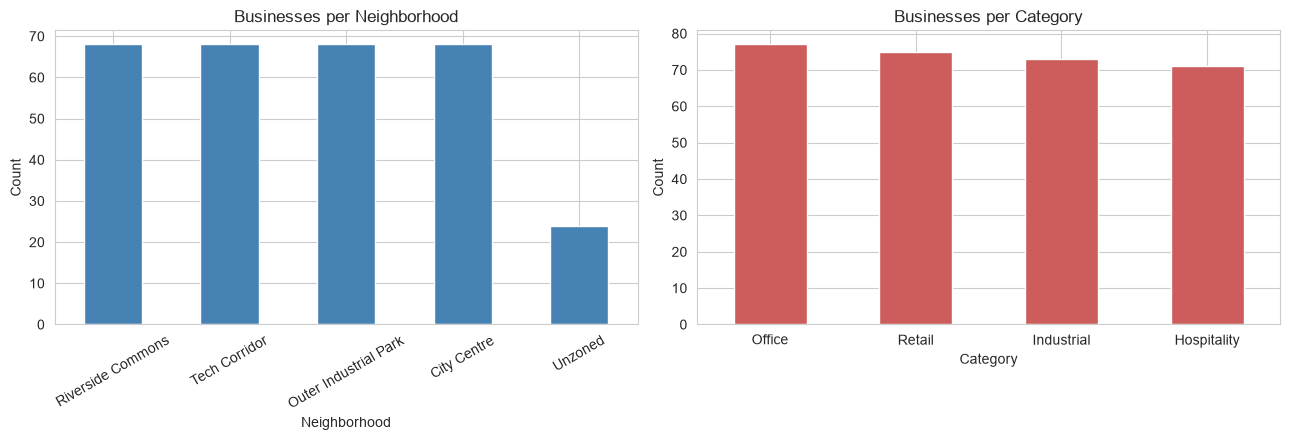

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["Neighborhood"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Businesses per Neighborhood")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

df["Category"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Businesses per Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

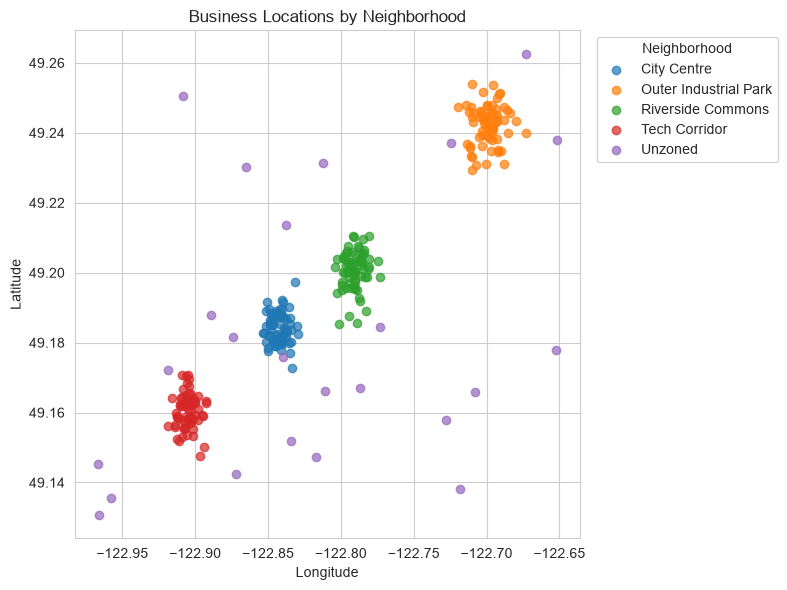

In [59]:
# create scatter plot of Longitude vs Latitude
# group data by Neighborhood and color each group differently
# add labels, legend, and show plot

plt.figure(figsize=(8, 6))
for neighborhood, group in df.groupby("Neighborhood"):
    plt.scatter(group["Longitude"], group["Latitude"], label=neighborhood, alpha=0.7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Business Locations by Neighborhood")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Neighborhood")
plt.tight_layout()
plt.show()

Summary: Analyzes ground truth spatial clusters, noting four dense neighborhoods and scattered noise/outlier points.

Summary: Part 1 clustering introduction, explaining unsupervised learning and partitioning coordinate data.

In [60]:
# geo_features = select columns [Longitude, Latitude] from df
# scaler_geo = initialize StandardScaler
# geo_scaled = scale geo_features using fit_transform
# print mean and standard deviation of coordinates before and after scaling

geo_features = df[["Longitude", "Latitude"]]
scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_features)

print("Before scaling:")
print("Mean:\n", geo_features.mean())
print("Std:\n", geo_features.std())

print("\nAfter scaling:")
print("Mean:", geo_scaled.mean(axis=0))
print("Std:", geo_scaled.std(axis=0))

Before scaling:
Mean:
 Longitude   -122.809990
Latitude      49.195751
dtype: float64
Std:
 Longitude    0.077615
Latitude     0.031342
dtype: float64

After scaling:
Mean: [-3.59352188e-14  5.75395587e-14]
Std: [1. 1.]


Summary: Explains K-Means algorithm steps, characteristics, and limitations in forcing outliers into clusters.

In [63]:
# define function kmeans_step_by_step(X, k, n_iterations, seed):
#     initialize random number generator with seed
#     randomly select k initial centroids from data points X
#     initialize history list with starting centroids
#     for iteration in range(n_iterations):
#         assign each point in X to nearest centroid using Euclidean distance
#         update each centroid to be the mean of its assigned points
#         append new centroids to history list
#     return history list and final labels
#
# run kmeans_step_by_step with geo_scaled, k=4, n_iterations=5
# print length of centroid history

def kmeans_step_by_step(X, k, n_iterations, seed):
    rng = np.random.default_rng(seed)
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx]
    history = [centroids.copy()]

    labels = None
    for _ in range(n_iterations):
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])
        centroids = new_centroids
        history.append(centroids.copy())

    return history, labels

centroid_history, final_labels = kmeans_step_by_step(geo_scaled, k=4, n_iterations=5, seed=RANDOM_STATE)
print(len(centroid_history))

6


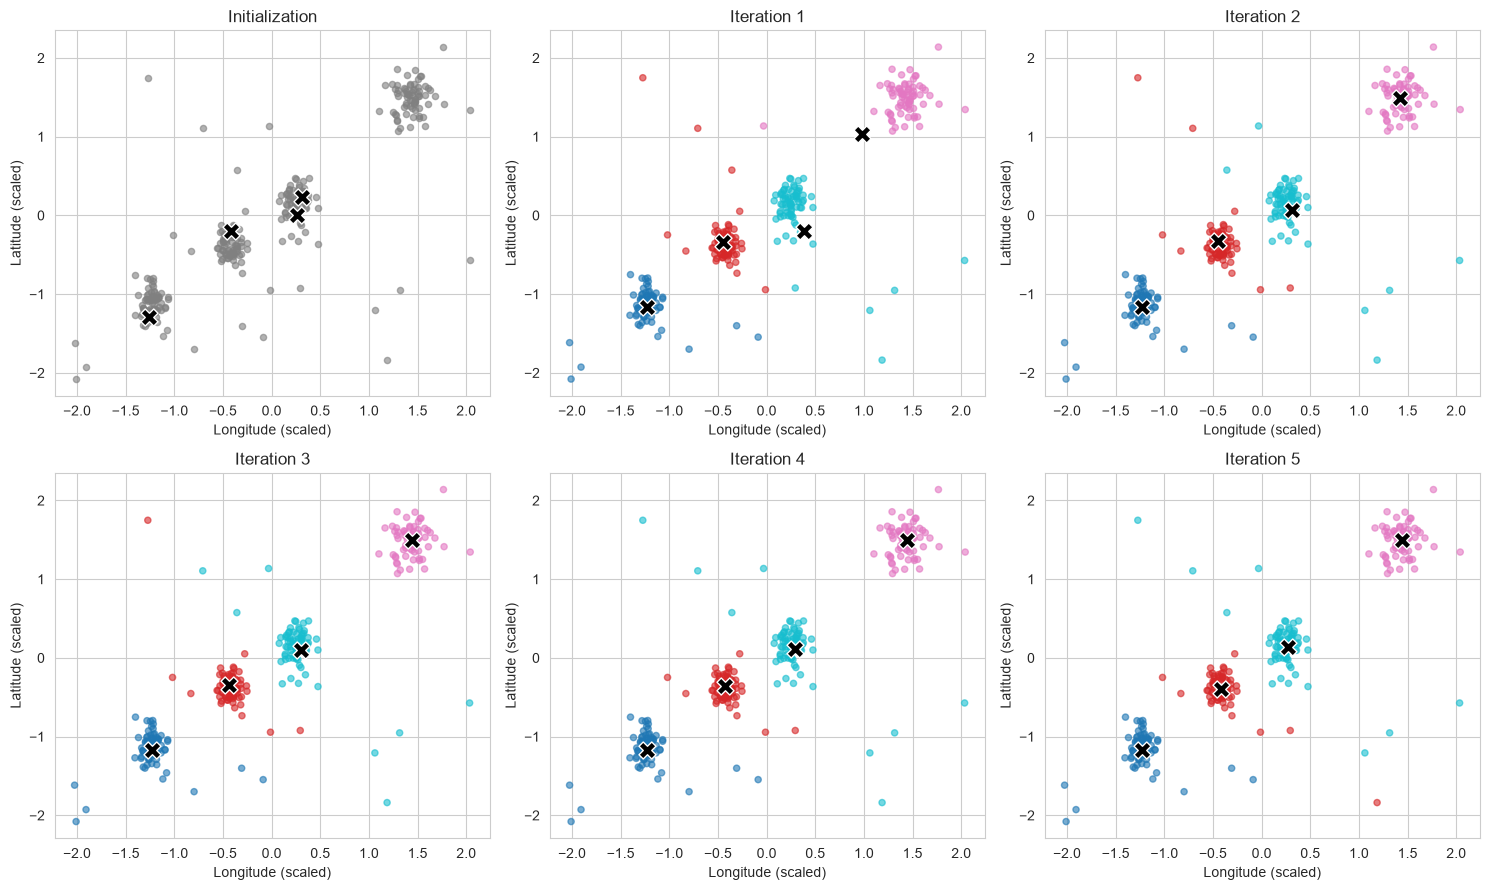

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    centroids = centroid_history[i]

    if i == 0:
        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], c="gray", alpha=0.6, s=20)
        ax.set_title("Initialization")
    else:
        distances = np.linalg.norm(geo_scaled[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], c=labels, cmap="tab10", alpha=0.6, s=20)
        ax.set_title(f"Iteration {i}")

    ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=150, edgecolor="white")
    ax.set_xlabel("Longitude (scaled)")
    ax.set_ylabel("Latitude (scaled)")

plt.tight_layout()
plt.show()

Summary: Observes K-Means convergence behavior and introduces elbow and silhouette metrics for selecting the cluster count k.

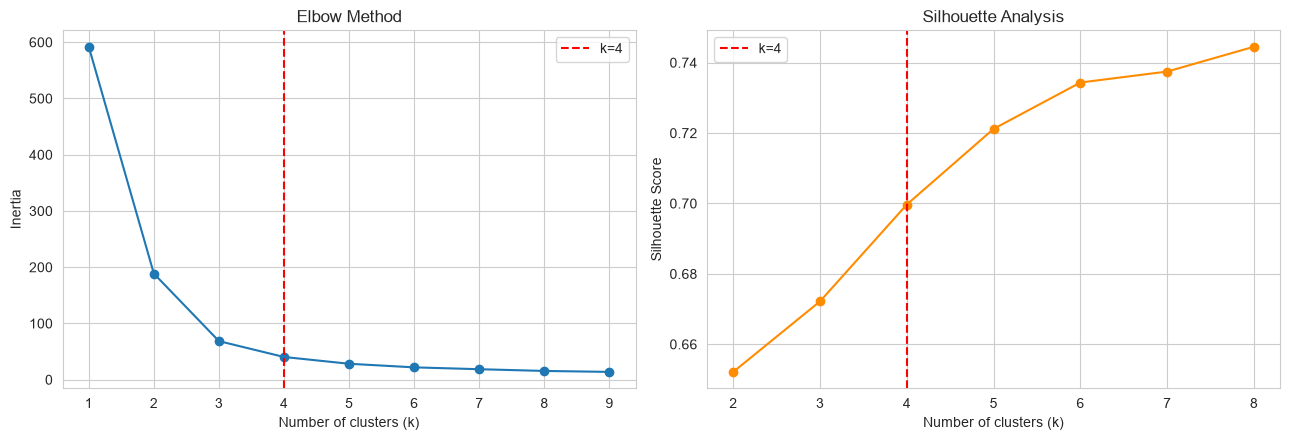

In [65]:
# initialize empty inertias list
# for k in range 1 to 9:
#     fit KMeans with k clusters on geo_scaled
#     append final inertia to inertias list

# initialize empty silhouette_scores dictionary
# for k in range 2 to 8:
#     fit KMeans with k clusters on geo_scaled
#     calculate silhouette score and store in dictionary

# create 1x2 subplot grid
# plot Elbow curve (inertia vs k) on first subplot
# plot Silhouette score vs k on second subplot
# draw optimal line at k=4 on both subplots and show plot

inertias = []
k_max = 10
for k in range(1, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(geo_scaled)
    inertias.append(km.inertia_)

silhouette_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters = k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(geo_scaled)
    silhouette_scores[k] = silhouette_score(geo_scaled, km_labels)

f, a = plt.subplots(1, 2, figsize=(13, 4.5))

a[0].plot(range(1, k_max), inertias, marker="o")
a[0].set_xlabel("Number of clusters (k)")
a[0].set_ylabel("Inertia")
a[0].set_title("Elbow Method")
a[0].axvline(x=4, color="red", linestyle="--", label="k=4")
a[0].legend()

a[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
a[1].set_xlabel("Number of clusters (k)")
a[1].set_ylabel("Silhouette Score")
a[1].set_title("Silhouette Analysis")
a[1].axvline(x=4, color="red", linestyle="--", label="k=4")
a[1].legend()

plt.tight_layout()
plt.show()


Summary: Evaluates elbow and silhouette diagnostic plots, identifying k=4 as the optimal choice.

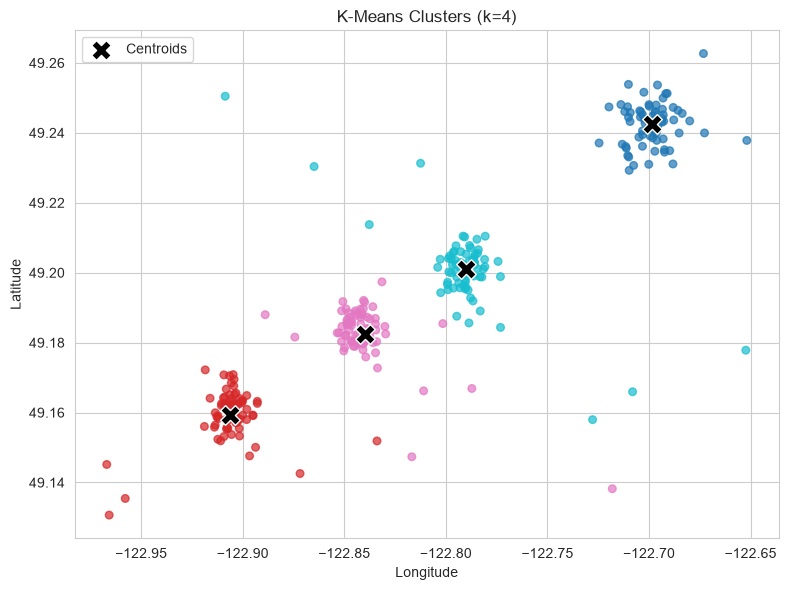

In [66]:
# kmeans_final = fit KMeans with k=4 on geo_scaled
# df[KMeans_Cluster] = predict cluster labels
# plot scatter plot of Longitude vs Latitude colored by KMeans_Cluster
# plot cluster centroids as black 'X' markers and show plot

kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["KMeans_Cluster"] = kmeans_final.fit_predict(geo_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["Longitude"], df["Latitude"], c=df["KMeans_Cluster"], cmap="tab10", alpha=0.7, s=30)

centroids_geo = scaler_geo.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_geo[:, 0], centroids_geo[:, 1], c="black", marker="X", s=200, edgecolor="white", label="Centroids")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clusters (k=4)")
plt.legend()
plt.tight_layout()
plt.show()

Summary: Asks how K-Means partitioned unzoned noise points.

In [67]:
# print cross-tabulation table between KMeans_Cluster and true Neighborhood labels

print(pd.crosstab(df["KMeans_Cluster"], df["Neighborhood"]))

Neighborhood    City Centre  Outer Industrial Park  Riverside Commons  \
KMeans_Cluster                                                          
0                         0                     68                  0   
1                         0                      0                  0   
2                        68                      0                  1   
3                         0                      0                 67   

Neighborhood    Tech Corridor  Unzoned  
KMeans_Cluster                          
0                           0        3  
1                          68        6  
2                           0        7  
3                           0        8  


Summary: Notes K-Means failure in handling noise/outliers, and motivates density-based spatial clustering.

Summary: Explains DBSCAN core/border/noise definitions, algorithm flow, and k-distance plot for choosing eps.

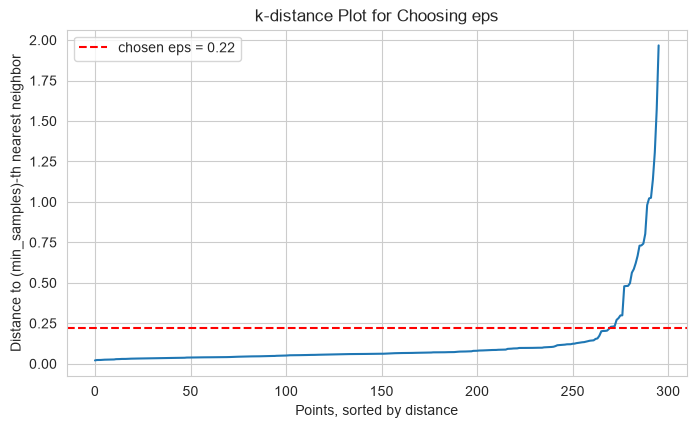

In [92]:
# min_samples = 5
# neighbors_model = fit NearestNeighbors with 5 neighbors on geo_scaled
# calculate distances of each point to its 5th nearest neighbor
# k_distances = sort distances in ascending order
# plot sorted k_distances, draw a horizontal line at chosen eps=0.22, and show plot

min_samples = 5

neighbours_model = NearestNeighbors(n_neighbors=min_samples)
neighbours_model.fit(geo_scaled)
distances, _ = neighbours_model.kneighbors(geo_scaled)

k_distances = np.sort_complex(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot (k_distances)
ax.axhline(0.22, color="red", linestyle="--", label="chosen eps = 0.22")
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to (min_samples)-th nearest neighbor")
ax.set_title("k-distance Plot for Choosing eps")
ax.legend() 
plt.show()


Summary: Identifies eps=0.22 at the knee of the k-distance plot.

In [106]:
# dbscan = fit DBSCAN with eps=0.22 and min_samples=5 on geo_scaled
# df[DBSCAN_Cluster] = predict cluster labels
# print number of clusters found and number of noise points flagged

dbscan = DBSCAN(eps=0.22, min_samples=6)
df["DBSCAN_Cluster"] = dbscan.fit_predict(geo_scaled)

n_clusters_dbscan = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)

n_noise_dbscan = (df["DBSCAN_Cluster"] == -1).sum()
print(f"Number of clusters: {n_clusters_dbscan} and number of noise points: {n_noise_dbscan}")

Number of clusters: 4 and number of noise points: 20


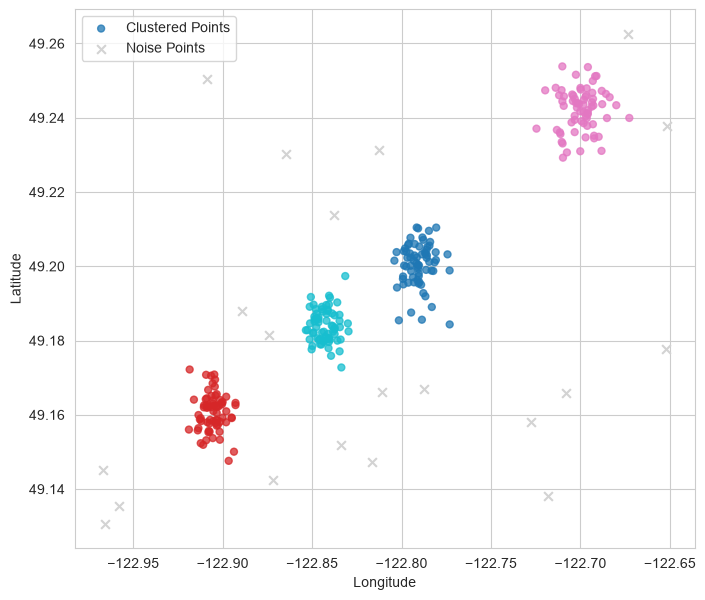

In [107]:
# create scatter plot of Longitude vs Latitude
# plot clustered points colored by DBSCAN_Cluster
# plot noise points (cluster = -1) as light gray 'x' markers and show plot

fig, ax = plt.subplots(figsize=(8,7))

noise_mask = df["DBSCAN_Cluster"] == -1
ax.scatter(
    df.loc[~noise_mask, "Longitude"], 
    df.loc[~noise_mask, "Latitude"], 
    c = df.loc[~noise_mask, "DBSCAN_Cluster"], 
    cmap="tab10", 
    s=25, 
    alpha=0.75, 
    label="Clustered Points"
)

ax.scatter(
    df.loc[noise_mask, "Longitude"], 
    df.loc[noise_mask, "Latitude"], 
    c = "lightgrey", 
    marker="x",
    s=40,
    label="Noise Points"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()

In [ ]:
print cross-tabulation table between DBSCAN_Cluster and true Neighborhood labels

Summary: Compares DBSCAN performance to K-Means, highlighting its success with noise but noting uniform density limits. Introduces HDBSCAN.

Summary: Explains HDBSCAN conceptual steps (reachability distance, minimum spanning tree, hierarchy, and condensed tree) which remove the need for a global eps.

In [ ]:
clusterer = fit HDBSCAN with min_cluster_size=10 and min_samples=5 on geo_scaled
df[HDBSCAN_Cluster] = predict cluster labels
df[HDBSCAN_Probability] = save membership probabilities
print number of clusters found and number of noise points flagged

In [ ]:
create scatter plot of Longitude vs Latitude
plot clustered points colored by HDBSCAN_Cluster with alpha set by HDBSCAN_Probability
plot noise points as light gray 'x' markers and show plot

Summary: Explains the condensed tree diagram visualizing cluster splits and branch stability.

In [ ]:
plot HDBSCAN condensed tree highlighting selected clusters and show plot

In [ ]:
print cross-tabulation table between HDBSCAN_Cluster and true Neighborhood labels

Summary: Evaluates HDBSCAN results, showing similar performance to DBSCAN but explaining its advantage for variable densities.

Summary: Provides a comparison table between K-Means, DBSCAN, and HDBSCAN across parameters, noise, shapes, and speed.

In [ ]:
create 1x3 grid of subplots
plot K-Means clusters on first subplot
plot DBSCAN clusters and noise on second subplot
plot HDBSCAN clusters and noise on third subplot
show plot

Summary: Recommends HDBSCAN (with noise filtering) as the most reliable geographic segmentation for the investor.

Summary: Part 2 dimensionality reduction introduction. Highlights the need to compress 4 numeric business attributes into 2 dimensions for visual inspection.

In [ ]:
feature_cols = [Floor_Area_sqm, Daily_Foot_Traffic, Community_Impact_Score, Annual_Revenue_k]
display descriptive statistics (min, max, mean, std) for feature_cols in df

Summary: Discusses scale differences (variance) across features, making standardization a mandatory step to prevent dominating features.

In [ ]:
X_raw = select feature_cols from df as matrix
scaler_features = initialize StandardScaler
X_scaled = scale X_raw using fit_transform
create 1x2 subplot grid
plot variance of features before standardization on first subplot
plot variance of features after standardization on second subplot
show plot

Summary: Notes equalized variance after scaling and introduces PCA.

Summary: Explains PCA mathematical steps (covariance, eigenvalues, sorting, and projection).

In [ ]:
X_pair = select [Floor_Area_sqm, Annual_Revenue_k] from df
X_pair_scaled = scale X_pair using StandardScaler
cov_matrix = calculate covariance matrix of X_pair_scaled
eigenvalues, eigenvectors = calculate eigenvalues and eigenvectors of cov_matrix
sort eigenvalues and eigenvectors in descending order
print covariance matrix, eigenvalues, and eigenvectors

In [ ]:
plot scatter plot of standardized Floor_Area_sqm vs Annual_Revenue_k
draw arrows from origin representing principal components (PC1, PC2) scaled by their eigenvalues
show plot

Summary: Notes that PC1 captures the shared diagonal trend of correlation between floor area and revenue.

In [ ]:
pca = initialize PCA
principal_components = project X_scaled onto principal components
explained = calculate variance explained ratio per component
cumulative = calculate cumulative sum of explained variance
plot scree plot (variance explained per PC and cumulative sum) and show plot
print explained and cumulative variance ratios

Summary: Reviews scree plot showing PC1 and PC2 capture ~89% of the total variance.

In [ ]:
df[PCA1], df[PCA2] = extract first two principal components
plot scatter plot of PCA1 vs PCA2 colored by Category and show plot

Summary: Highlights PCA's superpower of interpretable loading axes.

In [ ]:
loadings = create DataFrame from PCA components with rows as feature_cols and columns as PC1 to PC4
print loadings DataFrame

Summary: Interprets PC1 loading values, showing it models the exact trade-off between scale/revenue and foot-traffic/community impact.

Summary: Explains t-SNE probability maps, t-distribution projection, KL-divergence minimization, and local neighborhood focus.

In [ ]:
create 1x3 grid of subplots
for perplexity in [5, 30, 60]:
    tsne = fit t-SNE with perplexity and PCA initialization on X_scaled
    embedding = project X_scaled to 2D
    plot 2D scatter plot colored by Category
show plot

Summary: Evaluates perplexity parameter influence and notes t-SNE does not preserve global distances.

Summary: Steps of the UMAP algorithm. Explains k-nearest neighbors graph construction, fuzzy simplicial set representation, and low-dimensional projection optimization.

In [ ]:
create 1x3 grid of subplots
for n_neighbors in [5, 15, 40]:
    reducer = fit UMAP with n_neighbors and min_dist=0.1 on X_scaled
    embedding = project X_scaled to 2D
    plot 2D scatter plot colored by Category
show plot

Summary: Discusses UMAP n_neighbors tuning, noting tighter and more cohesive cluster projections compared to t-SNE.

Summary: Compares PCA, t-SNE, and UMAP features, strengths, and output characteristics.

In [ ]:
tsne_best = fit t-SNE with perplexity=30 on X_scaled
umap_best = fit UMAP with n_neighbors=15 on X_scaled
create 1x3 grid of subplots
plot PCA projection on first subplot
plot t-SNE projection on second subplot
plot UMAP projection on third subplot
color all plots by Category and show plot

Summary: Reviews side-by-side projections, comparing linear and non-linear properties in separating business categories.

Summary: Part 3 introduction. Combines spatial segments (HDBSCAN) with business attributes (PCA) for neighborhood profiling, dropping noise first.

In [ ]:
clean_df = filter df to exclude noise points (HDBSCAN_Cluster != -1)
print count of dropped noise points and remaining points
neighborhood_profile = group clean_df by Neighborhood and calculate mean of numeric columns
sort profile by avg_community_impact descending and print it

In [ ]:
plot scatter plot of Community_Impact_Score vs Annual_Revenue_k (log scale) grouped by Neighborhood
show plot

Summary: Profiles neighborhoods based on community impact vs. revenue trade-off, recommending Retail in City Centre or Tech Corridor office locations.

Summary: Concludes the lab, summarizing findings on spatial clustering and dimensionality reduction methods. Lists practice questions.